# AI Assignment Notebook



# PART 1 — Titanic Dataset Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Titanic Dataset

In [4]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Bar Plot: Survived vs Not Survived

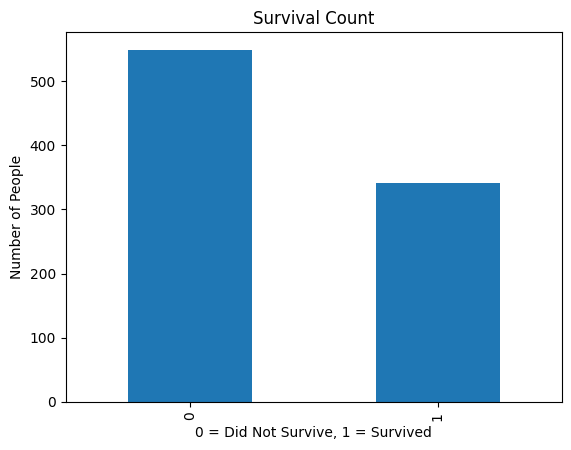

In [5]:
df['Survived'].value_counts().plot(kind='bar')
plt.title('Survival Count')
plt.xlabel('0 = Did Not Survive, 1 = Survived')
plt.ylabel('Number of People')
plt.show()

## Survival by Class and Gender

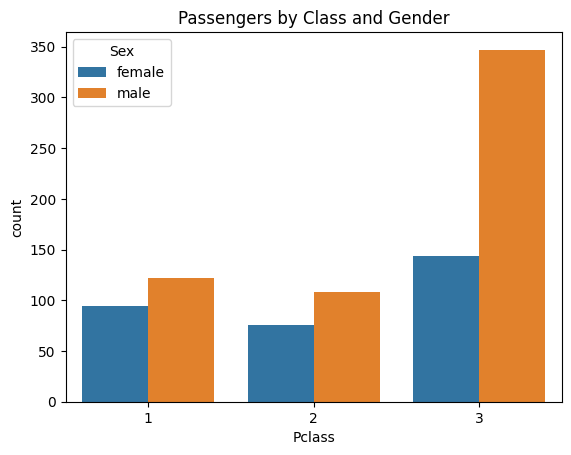

In [6]:
sns.countplot(x='Pclass', hue='Sex', data=df)
plt.title('Passengers by Class and Gender')
plt.show()

## Outlier Detection

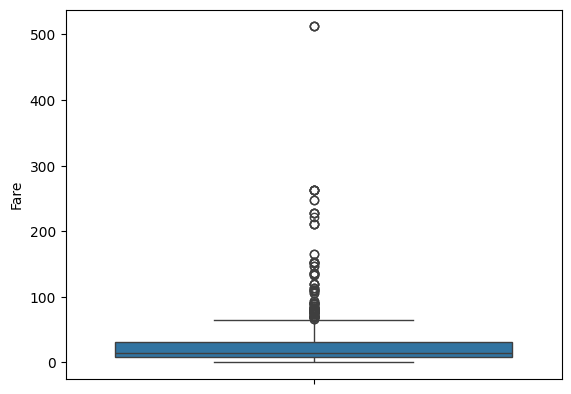

In [7]:
sns.boxplot(df['Fare'])
plt.show()

## Remove Outliers using IQR Method

In [8]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Fare'] >= Q1 - 1.5*IQR) & (df['Fare'] <= Q3 + 1.5*IQR)]

## Normalization Example

In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['Fare'] = scaler.fit_transform(df[['Fare']])

# PART 2 — Pandas Operations

## Series vs DataFrame Example

In [10]:
series_example = pd.Series([10,20,30])
dataframe_example = pd.DataFrame({'A':[1,2,3],'B':[4,5,6]})

series_example, dataframe_example

(0    10
 1    20
 2    30
 dtype: int64,
    A  B
 0  1  4
 1  2  5
 2  3  6)

## Add and Delete Column

In [12]:
df['Age_Double'] = df['Age'] * 2
df.drop('Age_Double', axis=1, inplace=True)

## Rename Column

In [13]:
df.rename(columns={'Pclass':'Passenger_Class'}, inplace=True)

## Logical Condition Example

In [14]:
df[df['Age'] > 30].head()

,PassengerId,Survived,Passenger_Class,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,0.816923,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,0.123846,NaN,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,0.797885,E46,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,0.408462,C103,S
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,0.481154,NaN,S


## Sorting

In [15]:
df.sort_values(by='Age')
df.sort_values(by='Age', ascending=False)

,PassengerId,Survived,Passenger_Class,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,0.461538,A23,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,0.119615,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,0.533142,A5,C
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,0.761603,NaN,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,0.119231,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
839,840,1,1,"Marechal, Mr. Pierre",male,NaN,0,0,11774,0.456923,C47,C
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,0.111218,NaN,C
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,0.146154,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,0.121474,NaN,S


## loc and iloc

In [16]:
df.loc[0]
df.iloc[0,2]

np.int64(3)

## Create Excel with Multiple Sheets

In [17]:
with pd.ExcelWriter('output_data.xlsx') as writer:
    df.to_excel(writer, sheet_name='Sheet1')
    df.head(10).to_excel(writer, sheet_name='Sheet2')
    df.describe().to_excel(writer, sheet_name='Sheet3')

# PART 3 — Pakistan E-commerce Dataset


## Load Dataset

In [124]:
df2 = pd.read_csv('Pakistan Largest Ecommerce Dataset.csv')
df2.head()

/tmp/ipykernel_526/2739705163.py:1: DtypeWarning: Columns (1,2,3,7,8,9,11,12,13,14,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('Pakistan Largest Ecommerce Dataset.csv')


,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


In [125]:
print(df2.columns)

Index(['item_id', 'status', 'created_at', 'sku', 'price', 'qty_ordered',
       'grand_total', 'increment_id', 'category_name_1',
       'sales_commission_code', 'discount_amount', 'payment_method',
       'Working Date', 'BI Status', ' MV ', 'Year', 'Month', 'Customer Since',
       'M-Y', 'FY', 'Customer ID', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25'],
      dtype='object')


In [126]:
df2 = df2.drop(['Unnamed: 21'], axis=1)
df2 = df2.drop(['Unnamed: 22'], axis=1)
df2 = df2.drop(['Unnamed: 23'], axis=1)
df2 = df2.drop(['Unnamed: 24'], axis=1)
df2 = df2.drop(['Unnamed: 25'], axis=1)

In [127]:
print(df2.columns)

Index(['item_id', 'status', 'created_at', 'sku', 'price', 'qty_ordered',
       'grand_total', 'increment_id', 'category_name_1',
       'sales_commission_code', 'discount_amount', 'payment_method',
       'Working Date', 'BI Status', ' MV ', 'Year', 'Month', 'Customer Since',
       'M-Y', 'FY', 'Customer ID'],
      dtype='object')


## Handle Null Values

In [128]:
print(df2.isnull().sum())

item_id                  464051
status                   464066
created_at               464051
sku                      464071
price                    464051
qty_ordered              464051
grand_total              464051
increment_id             464051
category_name_1          464215
sales_commission_code    601229
discount_amount          464051
payment_method           464051
Working Date             464051
BI Status                464051
 MV                      464051
Year                     464051
Month                    464051
Customer Since           464062
M-Y                      464051
FY                       464051
Customer ID              464062
dtype: int64


In [129]:


# Count of nulls
null_counts = df2.isnull().sum()

# Percent of nulls
null_percent = (null_counts / len(df2)) * 100

print(null_percent)

item_id                  44.255394
status                   44.256825
created_at               44.255394
sku                      44.257302
price                    44.255394
qty_ordered              44.255394
grand_total              44.255394
increment_id             44.255394
category_name_1          44.271034
sales_commission_code    57.337720
discount_amount          44.255394
payment_method           44.255394
Working Date             44.255394
BI Status                44.255394
 MV                      44.255394
Year                     44.255394
Month                    44.255394
Customer Since           44.256443
M-Y                      44.255394
FY                       44.255394
Customer ID              44.256443
dtype: float64


In [130]:
df2 = df2.drop([
    'item_id','sku','increment_id',
    'sales_commission_code','Working Date','BI Status',' MV ','Year','Month',
    'Customer Since','M-Y','FY','Customer ID'
], axis=1)

In [131]:
df2['grand_total'] = df2['grand_total'].fillna(df2['grand_total'].mean())
df2['price'] = df2['price'].fillna(df2['price'].mean())
df2['qty_ordered'] = df2['qty_ordered'].fillna(0)
df2['discount_amount'] = df2['discount_amount'].fillna(0)

In [132]:
df2['category_name_1'] = df2['category_name_1'].fillna('Unknown')
df2['status'] = df2['status'].fillna('Unknown')
df2['payment_method'] = df2['payment_method'].fillna('Unknown')

In [133]:
df2['created_at'] = pd.to_datetime(df2['created_at'], errors='coerce')
df2 = df2.dropna(subset=['created_at'])  # remove rows where date is missing

## Remove Duplicates

In [134]:

# Check which rows are duplicates
duplicate_rows = df2.duplicated()
print(duplicate_rows.value_counts())

False    392745
True     191779
Name: count, dtype: int64


In [135]:
 df2.drop_duplicates(inplace=True)

In [137]:


# Check which rows are duplicates
duplicate_rows = df2.duplicated()
print(duplicate_rows.value_counts())

False    392745
Name: count, dtype: int64


## Encode Categorical Variables

In [138]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df2['payment_method'] = le.fit_transform(df2['payment_method'])
df2['status'] = le.fit_transform(df2['status'])
df2['category_name_1'] = le.fit_transform(df2['category_name_1'])

## Correlation Matrix

In [139]:
correlation = df2.corr()
print(correlation['grand_total'].sort_values(ascending=False))

grand_total        1.000000
qty_ordered        0.685990
price              0.312536
discount_amount    0.093161
created_at         0.045031
category_name_1   -0.026303
payment_method    -0.032609
status            -0.046252
Name: grand_total, dtype: float64


## Scatter Plot Example

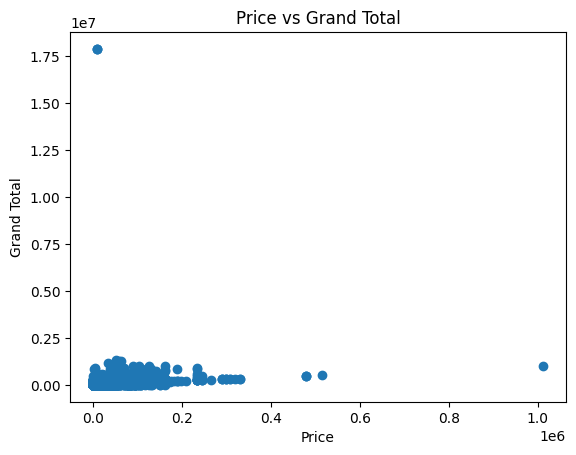

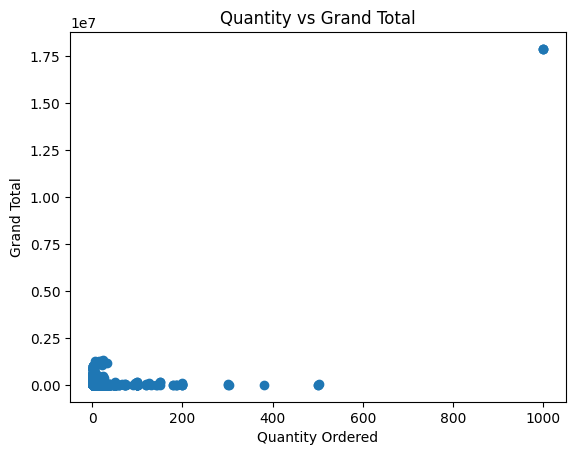

In [140]:
plt.scatter(df2['price'], df2['grand_total'])
plt.xlabel('Price')
plt.ylabel('Grand Total')
plt.title('Price vs Grand Total')
plt.show()

plt.scatter(df2['qty_ordered'], df2['grand_total'])
plt.xlabel('Quantity Ordered')
plt.ylabel('Grand Total')
plt.title('Quantity vs Grand Total')
plt.show()

## Best Selling Category

In [141]:
df2['category_name_1'].value_counts()

,count
category_name_1,
8,65209
9,64762
15,46653
0,38361
13,31129
1,31085
12,23638
6,22263
5,15228


In [142]:
# Count orders per category
best_selling = df2['category_name_1'].value_counts()

print("Best-selling category:")
print(best_selling.head(1))  # top 1 category

Best-selling category:
category_name_1
8    65209
Name: count, dtype: int64


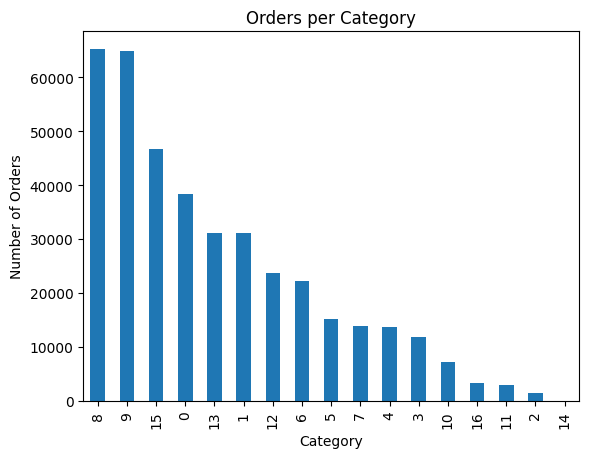

In [143]:
best_selling.plot(kind='bar', title='Orders per Category')
plt.xlabel('Category')
plt.ylabel('Number of Orders')
plt.show()

## Payment Method Frequency

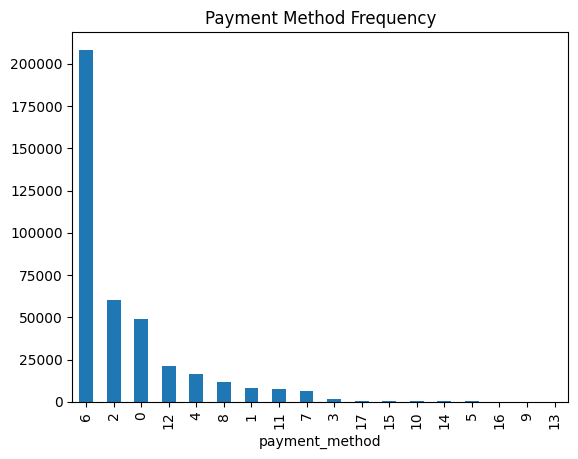

In [145]:
df2['payment_method'].value_counts().plot(kind='bar')

plt.title("Payment Method Frequency")
plt.show()

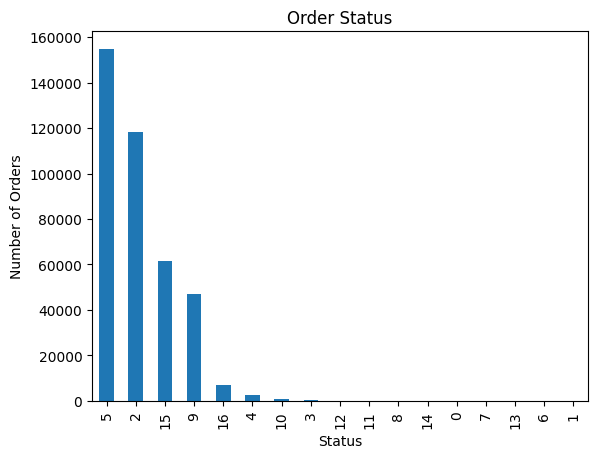

In [146]:
df2['status'].value_counts().plot(kind='bar', title='Order Status')
plt.xlabel('Status')
plt.ylabel('Number of Orders')
plt.show()

In [147]:
payment_status_corr = pd.crosstab(df2['payment_method'], df2['status'])
print(payment_status_corr)

status          0   1      2    3     4       5   6   7   8      9    10  11  \
payment_method                                                                 
0                0   0  28347   13     0   12871   0   0   2   2280  226   0   
1                0   0   4702    0     0    2443   0   0   0    270   33   0   
2                0   0  34297   42     0   15359   0   8   6   3156  335   0   
3                0   0   1111    0     0      26   0   0   0     42   20   0   
4                1   0  11105    4     0     502   0   0  15    687  173  33   
5                0   0      5    0     0     256   0   0   0     26    0   0   
6               14   2  18010  295  2576  104145   4   0   6  38231    0   0   
7                0   0     38   13     0    3805   0   0   0   1017   91   0   
8                0   0   6047    2     0    4225   0   0   0    322   10   0   
9                0   0      1    0     0       9   0   0   0      1    0   0   
10               0   0    271    4     0

In [149]:


df2['created_at'] = pd.to_datetime(df2['created_at'], errors='coerce')

# Drop rows with missing dates
df2 = df2.dropna(subset=['created_at'])

# Extract month number (1-12)
df2['order_month'] = df2['created_at'].dt.month
# Correlation between order month and category
month_category_corr = pd.crosstab(df2['order_month'], df2['category_name_1'])
print(month_category_corr)

category_name_1     0     1    2     3     4     5     6     7      8      9   \
order_month                                                                     
1                 1538  1769  121   542   429   876   947   757   2843   3052   
2                 2420  1623   81   681  1072  1047  1669   997   4031   4208   
3                 3089  2189  117  1057  1506  1333  1588  1010   4568   5595   
4                 1610  1737   97   567   527  1331  1406  1011   3892   3941   
5                 5964  2707  177  1354  2544  2219  2170  1589   7313   7939   
6                 1956  2294  130   620   783  1270  1255  1267   4348   4728   
7                 1653  2661  155  1029   821  1399  1584  1453   3542   7348   
8                 2496  3120  174  1084   957  1215  1597  1028   5310   6244   
9                 1075  1430   71   404   576   598   811   489   2318   3226   
10                1082  1710  139   672   774   712   906   740   3116   3276   
11               13288  7423

In [148]:
avg_no_discount = df2[df2['discount_amount']==0]['grand_total'].mean()
avg_with_discount = df2[df2['discount_amount']>0]['grand_total'].mean()

print("Average total without discount:", avg_no_discount)
print("Average total with discount:", avg_with_discount)

Average total without discount: 7750.436120001198
Average total with discount: 7588.595552295695
